In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8')   # updated style name


In [ ]:
#add your own file location here or path
df = pd.read_csv(r"C:\Users\dell\Downloads\Financials.csv")

In [4]:
df.head()
#df.info()

,Segment,Country,Product,Discount Band,Units Sold,Manufacturing Price,Sale Price,Gross Sales,Discounts,Sales,COGS,Profit,Date,Month Number,Month Name,Year
0,Government,Canada,Carretera,None,"$1,618.50",$3.00,$20.00,"$32,370.00",$-,"$32,370.00","$16,185.00","$16,185.00",01/01/2014,1,January,2014
1,Government,Germany,Carretera,None,"$1,321.00",$3.00,$20.00,"$26,420.00",$-,"$26,420.00","$13,210.00","$13,210.00",01/01/2014,1,January,2014
2,Midmarket,France,Carretera,None,"$2,178.00",$3.00,$15.00,"$32,670.00",$-,"$32,670.00","$21,780.00","$10,890.00",01/06/2014,6,June,2014
3,Midmarket,Germany,Carretera,None,$888.00,$3.00,$15.00,"$13,320.00",$-,"$13,320.00","$8,880.00","$4,440.00",01/06/2014,6,June,2014
4,Midmarket,Mexico,Carretera,None,"$2,470.00",$3.00,$15.00,"$37,050.00",$-,"$37,050.00","$24,700.00","$12,350.00",01/06/2014,6,June,2014


In [5]:
df.describe()

,Month Number,Year
count,700.000000,700.000000
mean,7.900000,2013.750000
std,3.377321,0.433322
min,1.000000,2013.000000
25%,5.750000,2013.750000
50%,9.000000,2014.000000
75%,10.250000,2014.000000
max,12.000000,2014.000000


In [6]:
#Cleaning the dataset

In [7]:
# Step 1: Strip spaces from column names
df.columns = df.columns.str.strip()

# Step 2: Define your financial columns
money_col1 = ["Units Sold", "Gross Sales"]

# Step 3: Clean each column thoroughly
for col in money_col1:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(r'[^\d\.\-]', '', regex=True)  # keep digits, dot, minus
        .replace('', '0')                           # replace empty string with '0'
        .astype(float)
    )


In [8]:
print(df[money_col1].head())
print(df.dtypes)

   Units Sold  Gross Sales
0      1618.5      32370.0
1      1321.0      26420.0
2      2178.0      32670.0
3       888.0      13320.0
4      2470.0      37050.0
Segment                 object
Country                 object
Product                 object
Discount Band           object
Units Sold             float64
Manufacturing Price     object
Sale Price              object
Gross Sales            float64
Discounts               object
Sales                   object
COGS                    object
Profit                  object
Date                    object
Month Number             int64
Month Name              object
Year                     int64
dtype: object


In [9]:
# Strip spaces from column names
df.columns = df.columns.str.strip()

money_cols = ["Discounts", "Sales", "COGS", "Profit"]

# Remove only the $ symbol first
for col in money_cols:
    df[col] = df[col].astype(str).str.replace(r'\$', '', regex=True)


In [10]:
for col in money_cols:
    df[col] = df[col].str.replace(r',', '', regex=True)


In [11]:
for col in money_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')


In [12]:
print(df[money_cols].head())
print(df.dtypes)

   Discounts    Sales     COGS   Profit
0        NaN  32370.0  16185.0  16185.0
1        NaN  26420.0  13210.0  13210.0
2        NaN  32670.0  21780.0  10890.0
3        NaN  13320.0   8880.0   4440.0
4        NaN  37050.0  24700.0  12350.0
Segment                 object
Country                 object
Product                 object
Discount Band           object
Units Sold             float64
Manufacturing Price     object
Sale Price              object
Gross Sales            float64
Discounts              float64
Sales                  float64
COGS                   float64
Profit                 float64
Date                    object
Month Number             int64
Month Name              object
Year                     int64
dtype: object


In [13]:
df.head()

,Segment,Country,Product,Discount Band,Units Sold,Manufacturing Price,Sale Price,Gross Sales,Discounts,Sales,COGS,Profit,Date,Month Number,Month Name,Year
0,Government,Canada,Carretera,None,1618.5,$3.00,$20.00,32370.0,NaN,32370.0,16185.0,16185.0,01/01/2014,1,January,2014
1,Government,Germany,Carretera,None,1321.0,$3.00,$20.00,26420.0,NaN,26420.0,13210.0,13210.0,01/01/2014,1,January,2014
2,Midmarket,France,Carretera,None,2178.0,$3.00,$15.00,32670.0,NaN,32670.0,21780.0,10890.0,01/06/2014,6,June,2014
3,Midmarket,Germany,Carretera,None,888.0,$3.00,$15.00,13320.0,NaN,13320.0,8880.0,4440.0,01/06/2014,6,June,2014
4,Midmarket,Mexico,Carretera,None,2470.0,$3.00,$15.00,37050.0,NaN,37050.0,24700.0,12350.0,01/06/2014,6,June,2014


In [14]:
# Strip spaces from column names
df.columns = df.columns.str.strip()

# Choose the columns where you want to remove $
cols_to_fix = ["Manufacturing Price", "Sale Price"]

for col0 in cols_to_fix:
    df[col0] = df[col0].astype(str).str.strip().str.replace(r'\$', '', regex=True)


In [15]:
for col0 in cols_to_fix:
    df[col0] = df[col0].str.replace(r',', '', regex=True)


In [16]:
for col0 in cols_to_fix:
    df[col0] = pd.to_numeric(df[col0], errors='coerce')


In [17]:
print(df[cols_to_fix].head(10))
print(df[cols_to_fix].dtypes)


   Manufacturing Price  Sale Price
0                  3.0        20.0
1                  3.0        20.0
2                  3.0        15.0
3                  3.0        15.0
4                  3.0        15.0
5                  3.0       350.0
6                  5.0        15.0
7                  5.0        12.0
8                  5.0        20.0
9                  5.0        12.0
Manufacturing Price    float64
Sale Price             float64
dtype: object


In [18]:
df.head()

,Segment,Country,Product,Discount Band,Units Sold,Manufacturing Price,Sale Price,Gross Sales,Discounts,Sales,COGS,Profit,Date,Month Number,Month Name,Year
0,Government,Canada,Carretera,None,1618.5,3.0,20.0,32370.0,NaN,32370.0,16185.0,16185.0,01/01/2014,1,January,2014
1,Government,Germany,Carretera,None,1321.0,3.0,20.0,26420.0,NaN,26420.0,13210.0,13210.0,01/01/2014,1,January,2014
2,Midmarket,France,Carretera,None,2178.0,3.0,15.0,32670.0,NaN,32670.0,21780.0,10890.0,01/06/2014,6,June,2014
3,Midmarket,Germany,Carretera,None,888.0,3.0,15.0,13320.0,NaN,13320.0,8880.0,4440.0,01/06/2014,6,June,2014
4,Midmarket,Mexico,Carretera,None,2470.0,3.0,15.0,37050.0,NaN,37050.0,24700.0,12350.0,01/06/2014,6,June,2014


In [19]:
df.isnull().sum()

Segment                 0
Country                 0
Product                 0
Discount Band           0
Units Sold              0
Manufacturing Price     0
Sale Price              0
Gross Sales             0
Discounts              53
Sales                   0
COGS                    0
Profit                 63
Date                    0
Month Number            0
Month Name              0
Year                    0
dtype: int64

In [20]:
df["Discounts"] = df["Gross Sales"] - df["Sales"]


In [21]:
df.isnull().sum()

Segment                 0
Country                 0
Product                 0
Discount Band           0
Units Sold              0
Manufacturing Price     0
Sale Price              0
Gross Sales             0
Discounts               0
Sales                   0
COGS                    0
Profit                 63
Date                    0
Month Number            0
Month Name              0
Year                    0
dtype: int64

In [22]:
df["Profit"] = df["Sales"] - df["COGS"]


In [23]:
df.head(10)

,Segment,Country,Product,Discount Band,Units Sold,Manufacturing Price,Sale Price,Gross Sales,Discounts,Sales,COGS,Profit,Date,Month Number,Month Name,Year
0,Government,Canada,Carretera,None,1618.5,3.0,20.0,32370.0,0.0,32370.0,16185.0,16185.0,01/01/2014,1,January,2014
1,Government,Germany,Carretera,None,1321.0,3.0,20.0,26420.0,0.0,26420.0,13210.0,13210.0,01/01/2014,1,January,2014
2,Midmarket,France,Carretera,None,2178.0,3.0,15.0,32670.0,0.0,32670.0,21780.0,10890.0,01/06/2014,6,June,2014
3,Midmarket,Germany,Carretera,None,888.0,3.0,15.0,13320.0,0.0,13320.0,8880.0,4440.0,01/06/2014,6,June,2014
4,Midmarket,Mexico,Carretera,None,2470.0,3.0,15.0,37050.0,0.0,37050.0,24700.0,12350.0,01/06/2014,6,June,2014
5,Government,Germany,Carretera,None,1513.0,3.0,350.0,529550.0,0.0,529550.0,393380.0,136170.0,01/12/2014,12,December,2014
6,Midmarket,Germany,Montana,None,921.0,5.0,15.0,13815.0,0.0,13815.0,9210.0,4605.0,01/03/2014,3,March,2014
7,Channel Partners,Canada,Montana,None,2518.0,5.0,12.0,30216.0,0.0,30216.0,7554.0,22662.0,01/06/2014,6,June,2014
8,Government,France,Montana,None,1899.0,5.0,20.0,37980.0,0.0,37980.0,18990.0,18990.0,01/06/2014,6,June,2014
9,Channel Partners,Germany,Montana,None,1545.0,5.0,12.0,18540.0,0.0,18540.0,4635.0,13905.0,01/06/2014,6,June,2014


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Segment              700 non-null    object 
 1   Country              700 non-null    object 
 2   Product              700 non-null    object 
 3   Discount Band        700 non-null    object 
 4   Units Sold           700 non-null    float64
 5   Manufacturing Price  700 non-null    float64
 6   Sale Price           700 non-null    float64
 7   Gross Sales          700 non-null    float64
 8   Discounts            700 non-null    float64
 9   Sales                700 non-null    float64
 10  COGS                 700 non-null    float64
 11  Profit               700 non-null    float64
 12  Date                 700 non-null    object 
 13  Month Number         700 non-null    int64  
 14  Month Name           700 non-null    object 
 15  Year                 700 non-null    int

In [25]:
df = df.astype({'Units Sold': 'int64', 'Manufacturing Price': 'int64', 'Sale Price': 'int64', 'Gross Sales': 'int64', 'Discounts': 'int64', 'Sales': 'int64', 'COGS': 'int64', 'Profit': 'int64'})

In [26]:
df.info()
df.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Segment              700 non-null    object
 1   Country              700 non-null    object
 2   Product              700 non-null    object
 3   Discount Band        700 non-null    object
 4   Units Sold           700 non-null    int64 
 5   Manufacturing Price  700 non-null    int64 
 6   Sale Price           700 non-null    int64 
 7   Gross Sales          700 non-null    int64 
 8   Discounts            700 non-null    int64 
 9   Sales                700 non-null    int64 
 10  COGS                 700 non-null    int64 
 11  Profit               700 non-null    int64 
 12  Date                 700 non-null    object
 13  Month Number         700 non-null    int64 
 14  Month Name           700 non-null    object
 15  Year                 700 non-null    int64 
dtypes: int64

,Segment,Country,Product,Discount Band,Units Sold,Manufacturing Price,Sale Price,Gross Sales,Discounts,Sales,COGS,Profit,Date,Month Number,Month Name,Year
0,Government,Canada,Carretera,None,1618,3,20,32370,0,32370,16185,16185,01/01/2014,1,January,2014
1,Government,Germany,Carretera,None,1321,3,20,26420,0,26420,13210,13210,01/01/2014,1,January,2014
2,Midmarket,France,Carretera,None,2178,3,15,32670,0,32670,21780,10890,01/06/2014,6,June,2014
3,Midmarket,Germany,Carretera,None,888,3,15,13320,0,13320,8880,4440,01/06/2014,6,June,2014
4,Midmarket,Mexico,Carretera,None,2470,3,15,37050,0,37050,24700,12350,01/06/2014,6,June,2014
5,Government,Germany,Carretera,None,1513,3,350,529550,0,529550,393380,136170,01/12/2014,12,December,2014
6,Midmarket,Germany,Montana,None,921,5,15,13815,0,13815,9210,4605,01/03/2014,3,March,2014
7,Channel Partners,Canada,Montana,None,2518,5,12,30216,0,30216,7554,22662,01/06/2014,6,June,2014
8,Government,France,Montana,None,1899,5,20,37980,0,37980,18990,18990,01/06/2014,6,June,2014
9,Channel Partners,Germany,Montana,None,1545,5,12,18540,0,18540,4635,13905,01/06/2014,6,June,2014


In [27]:

#Now data is cleaned and bow ready to analyse


In [28]:
df.describe(include='all')

,Segment,Country,Product,Discount Band,Units Sold,Manufacturing Price,Sale Price,Gross Sales,Discounts,Sales,COGS,Profit,Date,Month Number,Month Name,Year
count,700,700,700,700,700.000000,700.000000,700.000000,7.000000e+02,700.000000,7.000000e+02,700.000000,700.000000,700,700.000000,700,700.000000
unique,5,5,6,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16,NaN,12,NaN
top,Government,Canada,Paseo,High,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,01/06/2014,NaN,October,NaN
freq,300,140,202,245,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70,NaN,140,NaN
mean,NaN,NaN,NaN,NaN,1608.268571,96.477143,118.428571,1.827594e+05,13150.085714,1.696088e+05,145475.205714,24133.620000,NaN,7.900000,NaN,2013.750000
std,NaN,NaN,NaN,NaN,867.405966,108.602612,136.775515,2.542623e+05,22962.993141,2.367265e+05,203865.509908,42760.665025,NaN,3.377321,NaN,0.433322
min,NaN,NaN,NaN,NaN,200.000000,3.000000,7.000000,1.799000e+03,0.000000,1.655000e+03,918.000000,-40617.000000,NaN,1.000000,NaN,2013.000000
25%,NaN,NaN,NaN,NaN,905.000000,5.000000,12.000000,1.739175e+04,800.250000,1.592800e+04,7490.000000,2805.750000,NaN,5.750000,NaN,2013.750000
50%,NaN,NaN,NaN,NaN,1542.500000,10.000000,20.000000,3.798000e+04,2585.000000,3.553950e+04,22506.000000,9241.500000,NaN,9.000000,NaN,2014.000000
75%,NaN,NaN,NaN,NaN,2228.750000,250.000000,300.000000,2.790250e+05,15956.250000,2.610775e+05,245607.500000,22662.000000,NaN,10.250000,NaN,2014.000000


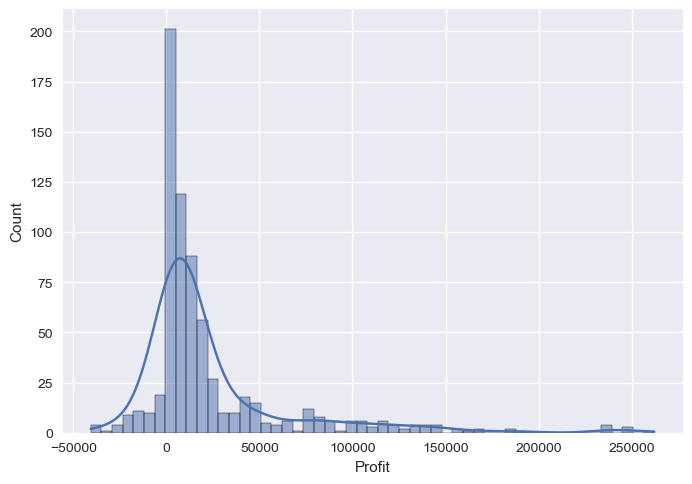

In [29]:
sns.histplot(df['Profit'], kde=True)
plt.show()

In [30]:
df.groupby('Product')['Profit'].mean().sort_values()

Product
Carretera     19642.849462
Velo          21155.669725
Montana       22738.989247
Paseo         23749.415842
VTT           27840.256881
Amarilla      29937.074468
Name: Profit, dtype: float64

In [31]:
df.groupby('Product')[['Sales','Profit']].mean().sort_values('Profit', ascending=False)


,Sales,Profit
Product,,
Amarilla,188798.829787,29937.074468
VTT,188182.513761,27840.256881
Paseo,163421.198020,23749.415842
Montana,165492.150538,22738.989247
Velo,167431.431193,21155.669725
Carretera,148551.397849,19642.849462


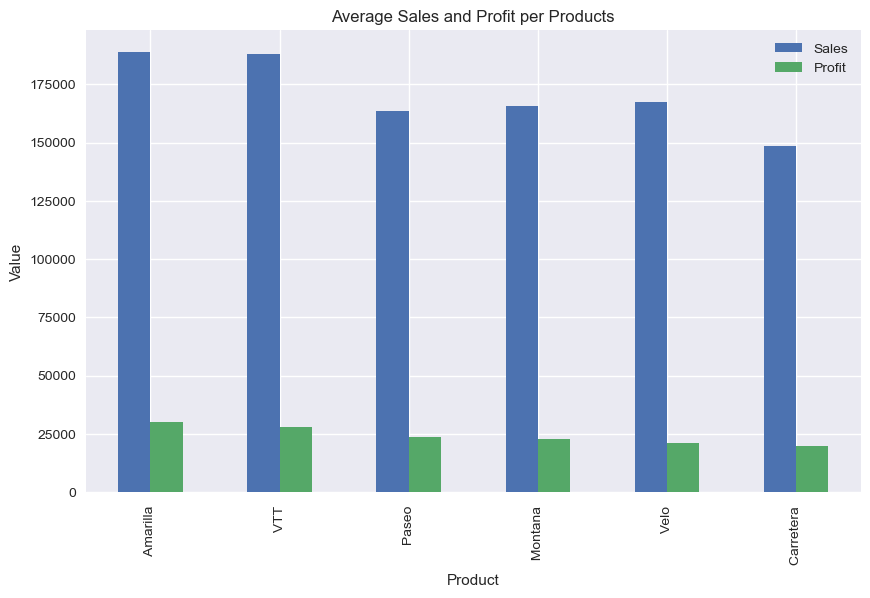

In [32]:
df.groupby('Product')[['Sales', 'Profit']].mean().sort_values('Profit', ascending=False).plot(kind='bar', figsize=(10,6))
plt.title('Average Sales and Profit per Products')
plt.ylabel('Value')
plt.show()

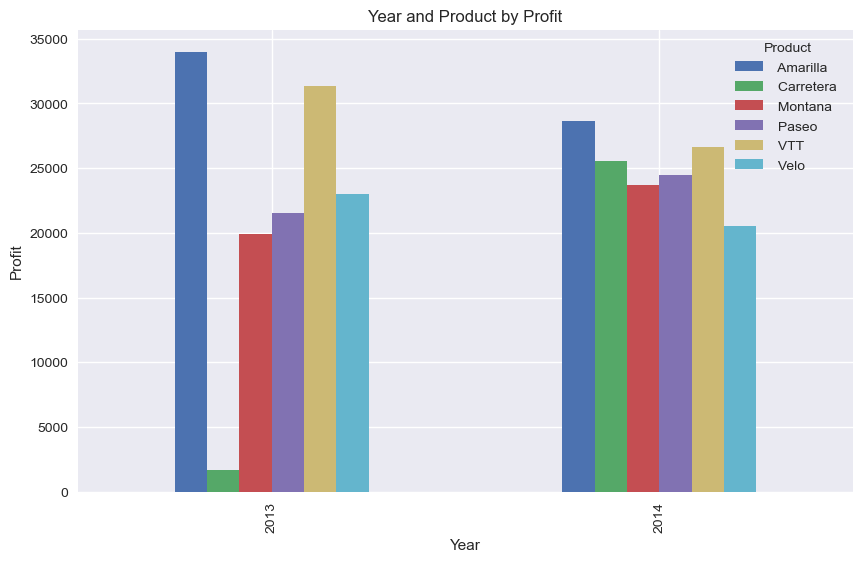

In [33]:
df.groupby(['Year','Product'])['Profit'].mean().unstack().plot(kind='bar', figsize=(10,6))
#df.groupby('Product')['Discounts'].mean()
plt.title('Year and Product by Profit')
plt.xlabel('Year')
plt.ylabel('Profit')
plt.show()


In [34]:
df['Country'].unique()


array(['Canada', 'Germany', 'France', 'Mexico',
       'United States of America'], dtype=object)

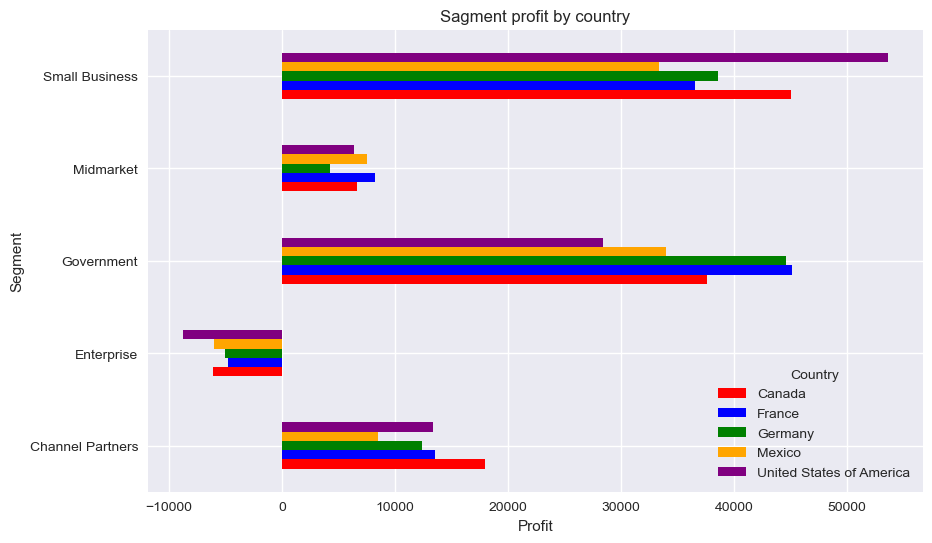

In [35]:
color_map = {
    'Canada': 'red',
    'Germany': 'blue',
    'France': 'green',
    'Mexico': 'orange',
    'United States of America': 'purple'}


df.groupby(['Segment', 'Country'])['Profit'].mean().unstack().plot(kind='barh', figsize=(10,6), color=[color_map[c] for c in df['Country'].unique()] 
)
plt.title('Sagment profit by country')
plt.xlabel('Profit')
plt.show()


<Axes: xlabel='Month Name'>

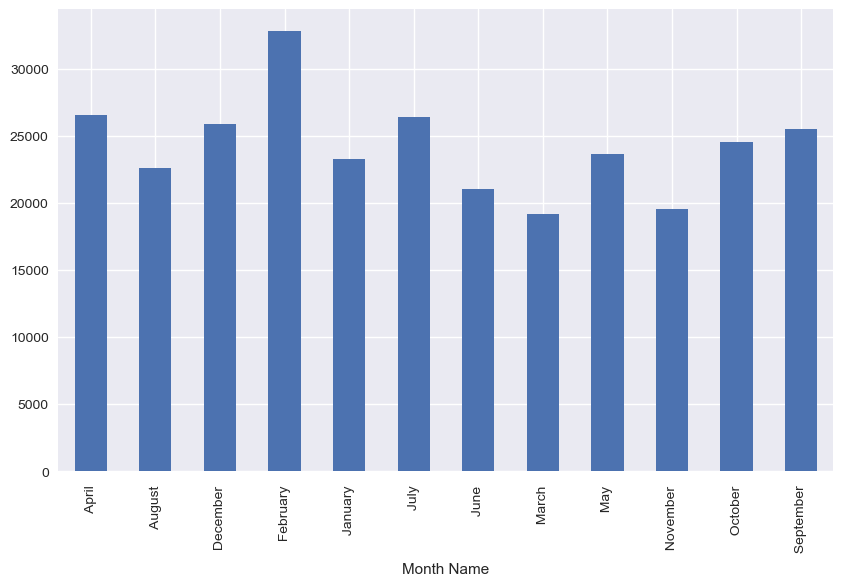

In [36]:
df.groupby('Month Name')['Profit'].mean().plot(kind='bar', figsize=(10,6))

<Axes: xlabel='Month Name'>

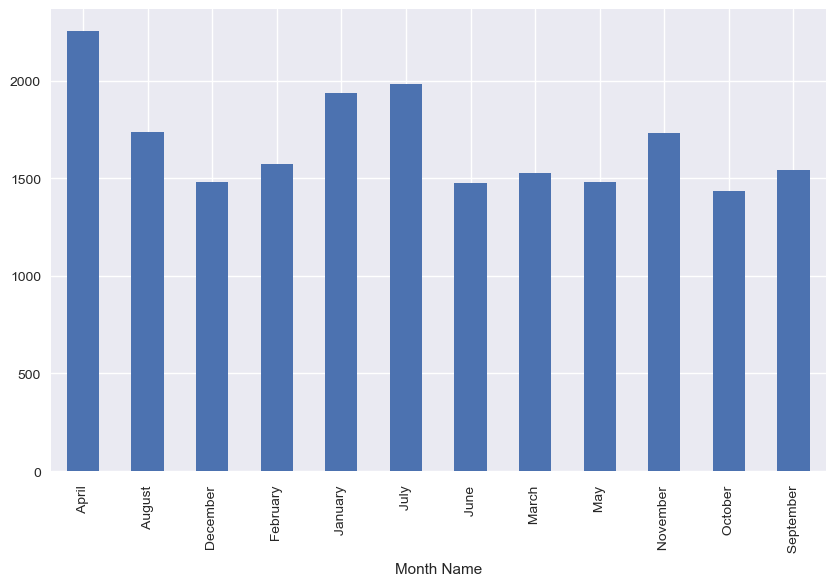

In [37]:
df.groupby('Month Name')['Units Sold'].mean().plot(kind='bar', figsize=(10,6))

In [38]:
df.corr(numeric_only=True)


,Units Sold,Manufacturing Price,Sale Price,Gross Sales,Discounts,Sales,COGS,Profit,Month Number,Year
Units Sold,1.000000,-0.029649,-6.506997e-02,0.327219,0.253045,0.326912,0.331693,0.228437,-1.035760e-01,6.384106e-02
Manufacturing Price,-0.029649,1.000000,7.078637e-02,0.049852,0.020578,0.051549,0.046857,0.061986,5.021388e-03,-9.271955e-04
Sale Price,-0.065070,0.070786,1.000000e+00,0.808250,0.641693,0.805878,0.799335,0.650498,5.122894e-17,-4.211383e-15
Gross Sales,0.327219,0.049852,8.082502e-01,1.000000,0.782487,0.998174,0.994519,0.784511,-3.496559e-02,4.443487e-02
Discounts,0.253045,0.020578,6.416926e-01,0.782487,1.000000,0.743449,0.782932,0.383091,-5.359053e-02,2.239712e-02
Sales,0.326912,0.051549,8.058779e-01,0.998174,0.743449,1.000000,0.992244,0.805464,-3.235730e-02,4.555384e-02
COGS,0.331693,0.046857,7.993354e-01,0.994519,0.782932,0.992244,1.000000,0.725547,-3.615839e-02,4.731018e-02
Profit,0.228437,0.061986,6.504977e-01,0.784511,0.383091,0.805464,0.725547,1.000000,-6.744121e-03,2.663402e-02
Month Number,-0.103576,0.005021,5.122894e-17,-0.034966,-0.053591,-0.032357,-0.036158,-0.006744,1.000000e+00,-4.276786e-01
Year,0.063841,-0.000927,-4.211383e-15,0.044435,0.022397,0.045554,0.047310,0.026634,-4.276786e-01,1.000000e+00


<Axes: xlabel='Month Name'>

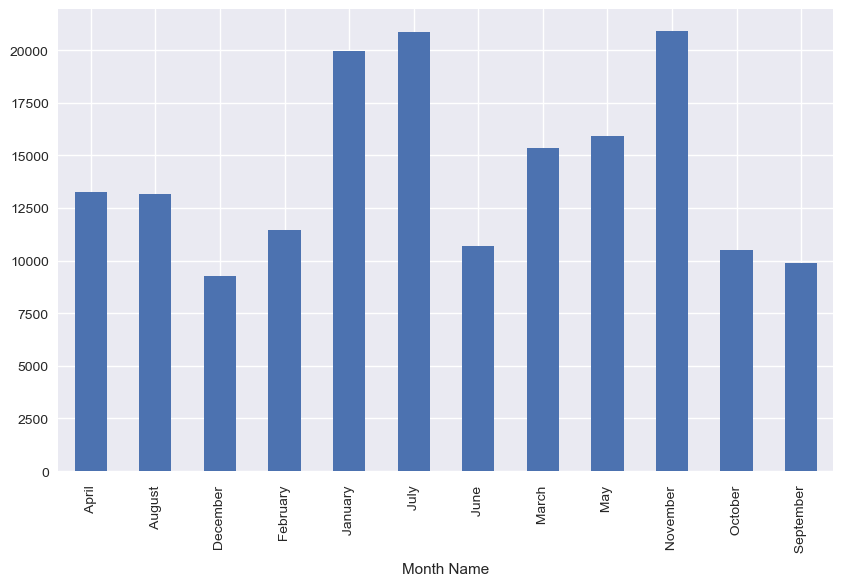

In [39]:
df.groupby('Month Name')['Discounts'].mean().plot(kind='bar', figsize=(10,6))

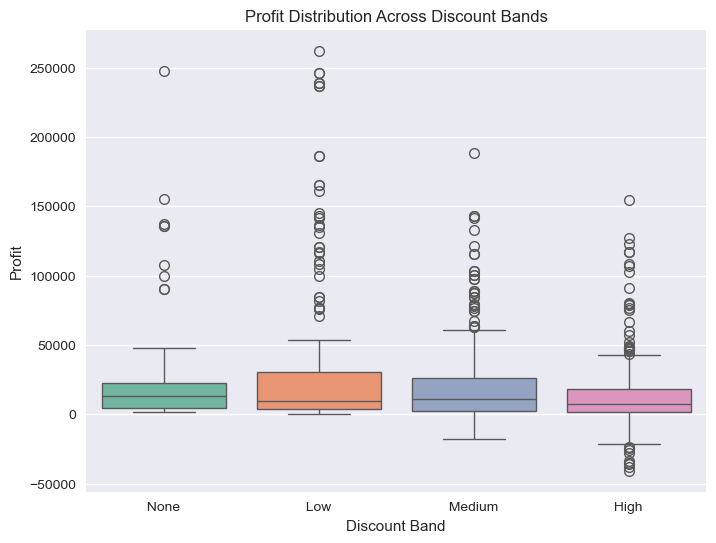

In [40]:
plt.figure(figsize=(8,6))
sns.boxplot(x="Discount Band", y="Profit", data=df, hue="Discount Band", palette="Set2", legend=False)
plt.title("Profit Distribution Across Discount Bands")
plt.title("Profit Distribution Across Discount Bands")
plt.show()

In [ ]:
#insights 
#1. Most profit values cluster near zero, with fewer high-profit outliers
#2. Products like Amarilla and VTT consistently outperform others in both sales and profit
#3. The USA dominates in Small Business segment profits, while other countries vary across segments
#4. February has the highest average profit, while March is the lowest
#5. Gross Sales, Sales, and COGS are almost perfectly correlated, showing the cost structure is tightly linked to revenue
#6. April, January, and July show the highest average units sold, while October and June are weaker
#7. January, July, and November have the highest average discounts, while December and September are the lowest
#8. Higher discounts show greater variability in profit and tend to lower median profits
#9. low discounts are associated with more stable and higher profits

In [42]:
df.to_csv("Cleaned_Financuaks.csv", index=False)